In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data=pd.read_csv("Car_Sales00.csv")
data.head(2)

,name,year,km_driven,fuel,seller_type,transmission,owner,selling_price
0,Maruti 800 AC,2007,70000,Petrol,Individual,Manual,0,60000
1,Maruti Wagon R LXI Minor,2007,50000,Petrol,Individual,Manual,0,135000


In [3]:
data.isnull().sum()

name             0
year             0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
selling_price    0
dtype: int64

In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   name           4340 non-null   str  
 1   year           4340 non-null   int64
 2   km_driven      4340 non-null   int64
 3   fuel           4340 non-null   str  
 4   seller_type    4340 non-null   str  
 5   transmission   4340 non-null   str  
 6   owner          4340 non-null   int64
 7   selling_price  4340 non-null   int64
dtypes: int64(4), str(4)
memory usage: 271.4 KB


In [5]:
from sklearn.preprocessing import LabelEncoder

Label Encoding:name

In [6]:
name_le=LabelEncoder()
data['name']=name_le.fit_transform(data["name"])

Label Encoding:fuel

In [7]:
fuel_le=LabelEncoder()
data['fuel']=fuel_le.fit_transform(data["fuel"])

Label Encoding:seller_type

In [8]:
seller_type_le=LabelEncoder()
data['seller_type']=seller_type_le.fit_transform(data["seller_type"])

Label Encoding:transmission

In [9]:
transmission_le=LabelEncoder()
data['transmission']=transmission_le.fit_transform(data["transmission"])

In [10]:
data.head(5)

,name,year,km_driven,fuel,seller_type,transmission,owner,selling_price
0,775,2007,70000,4,1,1,0,60000
1,1041,2007,50000,4,1,1,0,135000
2,505,2012,100000,1,1,1,0,600000
3,118,2017,46000,4,1,1,0,250000
4,279,2014,141000,1,1,1,1,450000


In [11]:
x=data.iloc[:,:-1] #input
y=data["selling_price"] #output

Scaling

In [12]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
x=pd.DataFrame(ss.fit_transform(x),columns=x.columns)
x

,name,year,km_driven,fuel,seller_type,transmission,owner
0,0.058522,-1.445074,0.081139,1.014993,0.448192,0.339276,-0.723423
1,0.723520,-1.445074,-0.347689,1.014993,0.448192,0.339276,-0.723423
2,-0.616477,-0.258795,0.724381,-0.974051,0.448192,0.339276,-0.723423
3,-1.583975,0.927485,-0.433455,1.014993,0.448192,0.339276,-0.723423
4,-1.181476,0.215717,1.603479,-0.974051,0.448192,0.339276,1.382316
...,...,...,...,...,...,...,...
4335,-0.373977,0.215717,0.295553,-0.974051,0.448192,0.339276,1.382316
4336,-0.376477,0.215717,0.295553,-0.974051,0.448192,0.339276,1.382316
4337,0.063522,-0.970563,0.359877,1.014993,0.448192,0.339276,1.382316
4338,-0.926476,0.690229,0.509967,-0.974051,0.448192,0.339276,-0.723423


In [13]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=43,test_size=0.2)

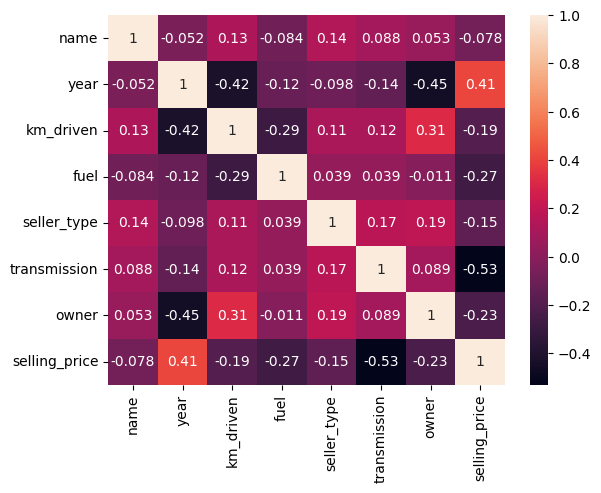

In [14]:
sns.heatmap(data=data.corr(),annot=True)
plt.show()

In [15]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [16]:
rf=RandomForestRegressor(n_estimators=256)
rf.fit(x_train,y_train)
rf.score(x_train,y_train)*100,rf.score(x_test,y_test)*100

(97.38622122740436, 70.33419227350939)

In [17]:
new_data=pd.DataFrame([["Maruti 800 AC",2007,70000,"Petrol","Individual","Manual",0]],columns=x_train.columns)
new_data['fuel'] = fuel_le.transform(new_data["fuel"])
new_data['name'] = name_le.transform(new_data[ "name"])
new_data['seller_type'] = seller_type_le.transform(new_data[ "seller_type"])
new_data['transmission'] = transmission_le.transform(new_data[ "transmission"])
new_data = pd.DataFrame(ss.transform(new_data),columns=new_data.columns)

In [18]:
rf.predict(new_data)

array([62851.5625])

In [19]:
mean_absolute_error(y_test,rf.predict(x_test))

117533.78976304484